# Churn Guard - предсказание оттока клиентов телеком-оператора

**Итоговый проект курса Data Science & AI**
Трек: **гибридный (ML + AI)**

---

## Как читать этот ноутбук

Я старалась писать не только код, но и зачем я делаю каждый шаг и что из
него следует. Без этих пояснений остался бы просто набор ячеек, по которому
непонятно, почему выбрана именно такая модель и метрика.

## Постановка задачи

**Бизнес-проблема.** Телеком-оператор теряет примерно четверть клиентов в год.
Привлечь нового клиента стоит в разы дороже, чем удержать существующего,
поэтому компания хочет знать заранее: **кто собирается уйти**.

**Задача ML.** Бинарная классификация: по профилю клиента предсказать `Churn` -
уйдёт (1) или останется (0).

**Задача AI.** Модель выдаёт число `0.89`. Менеджеру по удержанию это ничего не говорит.
Языковая модель превращает результат в понятное объяснение: почему риск высокий
и что конкретно предложить клиенту.

**Что считаем успехом.**

| Уровень | Критерий |
|---|---|
| Технический | ROC-AUC заметно выше 0.5 (случайной модели) |
| Бизнесовый | список «кому звонить» в несколько раз точнее случайного обзвона |
| Продуктовый | менеджер без знания Python может открыть страницу и получить ответ |

**Почему именно эта задача.** Отток - это классика, по которой легко проверить
себя: результат известен заранее (ROC-AUC ≈ 0.84 на этом датасете считается
хорошим), а значит, если у меня получится сильно больше - почти наверняка
где-то утечка данных, а не гениальность.

---
## 0. Настройка окружения

Первое правило воспроизводимости: путь к данным не пишем строкой в ячейке,
а берём из `src/config.py`. Тогда ноутбук и веб-приложение работают с
одними и теми же данными и одной и той же логикой очистки.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")          # делаем модули проекта импортируемыми
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

from config import FIGURES_DIR, TARGET, RANDOM_STATE

np.random.seed(RANDOM_STATE)          # фиксируем случайность
print("Готово. Графики будут сохраняться в", FIGURES_DIR)

Готово. Графики будут сохраняться в /Users/yerlandana/Desktop/final_project_ds/reports/figures


---
## 1. Загрузка данных и первый взгляд

**Датасет:** Telco Customer Churn - 7043 клиента, 19 признаков + таргет.
Источник: OpenML (id 42178), это та же самая таблица, что лежит на Kaggle.

Первое, что делает аналитик с новой таблицей, - три команды: `shape`, `head`, `info`.
Не ради ритуала: они отвечают на вопросы «сколько данных», «как они выглядят»
и «какого типа каждая колонка». Третий вопрос - самый коварный, сейчас увидим почему.

In [2]:
from data import load_raw

raw = load_raw()
print("Размер таблицы:", raw.shape)
raw.head()

Размер таблицы: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### Первая находка: `TotalCharges` - это текст

Смотрим на вывод `info()`: колонка `TotalCharges` имеет тип `object`, то есть строка.
Но «сумма всех платежей» обязана быть числом. Значит, внутри есть что-то,
что мешает pandas распознать её как число. Найдём эти строки.

In [4]:
broken = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()
print(f"Проблемных строк: {broken.sum()}")
raw.loc[broken, ["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Проблемных строк: 11


,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,0,52.55,' ','Two year',No
753,0,20.25,' ','Two year',No
936,0,80.85,' ','Two year',No
1082,0,25.75,' ','Two year',No
1340,0,56.05,' ','Two year',No
3331,0,19.85,' ','Two year',No
3826,0,25.35,' ','Two year',No
4380,0,20.00,' ','Two year',No
5218,0,19.70,' ','One year',No
6670,0,73.35,' ','Two year',No


**Разбор находки.** У всех 11 «сломанных» строк `tenure = 0` - это клиенты,
которые подключились буквально вчера и ещё ни разу не платили. В ячейке стоит пробел `' '`.

Как это чинить? Есть три варианта:

| Вариант | Что получится | Оценка |
|---|---|---|
| Удалить строки | Потеряем 11 новых клиентов | Плохо: новички - самая рискованная группа, их нельзя выбрасывать |
| Заполнить медианой (≈1400) | Клиент с 0 месяцев «заплатил» 1400 | Плохо: это ложь, которую модель примет за правду |
| Поставить 0 | Не платил ни разу - заплатил 0 | **Верно: это следует из смысла данных** |

Вывод: **пропуски нужно заполнять по смыслу задачи, а не автоматически
через `.fillna(median)`**. Сначала надо понять, почему значение пропало.

### Вторая находка: кавычки внутри значений

In [5]:
print("Contract:", raw["Contract"].unique())
print("PaymentMethod:", raw["PaymentMethod"].unique())

Contract: ['Month-to-month' "'One year'" "'Two year'"]
PaymentMethod: ["'Electronic check'" "'Mailed check'" "'Bank transfer (automatic)'"
 "'Credit card (automatic)'"]


Значения приехали как `"'One year'"` - с апострофами внутри строки. Это след формата
ARFF, в котором датасет хранится на OpenML. Если это не убрать, `'One year'` и `One year`
станут **двумя разными категориями**, и one-hot кодирование создаст лишние колонки.

### Третья находка: дубликаты

In [6]:
print("Полных дубликатов строк:", raw.duplicated().sum())
raw[raw.duplicated(keep=False)].sort_values(list(raw.columns)).head(4)

Полных дубликатов строк: 22


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',69.2,69.2,Yes
6764,Female,0,No,No,1,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',69.2,69.2,Yes
4495,Female,0,No,No,1,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.1,70.1,Yes
6267,Female,0,No,No,1,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.1,70.1,Yes


В датасете нет `customerID` (OpenML его убрал), поэтому 22 полностью одинаковые
строки неотличимы. Это могли быть разные реальные люди с одинаковым тарифом -
но если такая строка попадёт и в обучение, и в тест, модель на тесте фактически
**увидит ответ**, и метрика окажется завышенной. Это называется **утечкой данных
(data leakage)**. Теряем 0.3% данных, зато получаем честную оценку - размен выгодный.

### Применяем очистку

Вся логика выше собрана в функцию `clean()` в `src/data.py`. Почему функция, а не
десять ячеек в ноутбуке? Потому что ровно те же шаги нужно будет применить к
новому клиенту в веб-приложении. Если очистка живёт только в ноутбуке, получится
классическое «в ноутбуке работало, а на сайте сломалось».

In [7]:
from data import load_clean

df = load_clean()
print(f"Было:  {raw.shape}")
print(f"Стало: {df.shape}")
print(f"Пропусков: {df.isna().sum().sum()}")
print(f"Тип TotalCharges: {df['TotalCharges'].dtype}")
df.head(3)

Было:  (7043, 20)
Стало: (7021, 20)


Пропусков: 0
Тип TotalCharges: float64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


---
# 2. Разведочный анализ данных (EDA)

EDA - это не «нарисовать побольше графиков». Это поиск ответов на конкретные вопросы.
Я задаю себе пять, и каждый график ниже отвечает ровно на один из них:

1. Насколько несбалансирован таргет? *(от этого зависит выбор метрики)*
2. Какие категориальные признаки сильнее всего связаны с оттоком?
3. Как ведут себя числовые признаки у ушедших и оставшихся?
4. Есть ли мультиколлинеарность? *(важно для линейной модели)*
5. Нет ли утечки данных? *(признака, который «знает ответ»)*

## 2.1. Вопрос первый: баланс классов

Почему это самый первый вопрос? Потому что от ответа зависит, какой метрикой
вообще можно пользоваться.

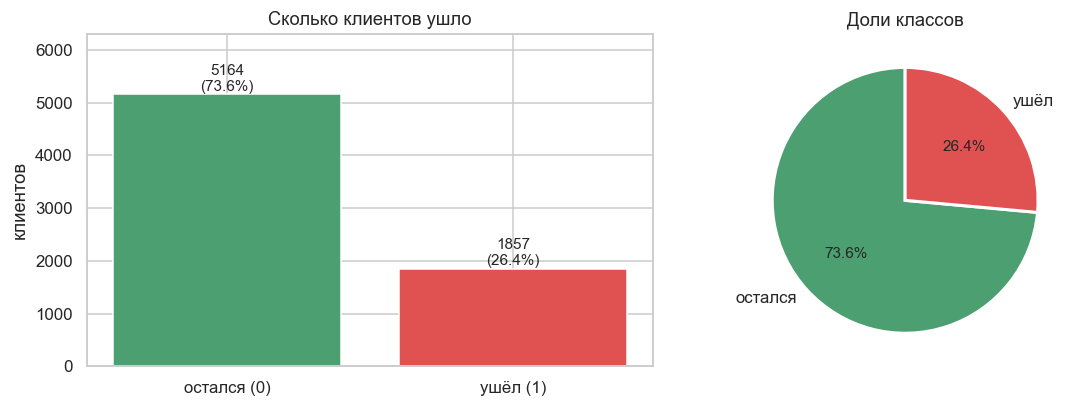

Доля ушедших: 26.4%
Accuracy «модели», которая всегда говорит «останется»: 73.6%


In [8]:
counts = df[TARGET].value_counts()
share = df[TARGET].mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(["остался (0)", "ушёл (1)"], counts.values, color=["#4c9f70", "#e05252"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 60, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=10)
ax[0].set(title="Сколько клиентов ушло", ylabel="клиентов")
ax[0].set_ylim(0, counts.max() * 1.22)

ax[1].pie([1 - share, share], labels=["остался", "ушёл"], autopct="%1.1f%%",
          colors=["#4c9f70", "#e05252"], startangle=90,
          wedgeprops={"edgecolor": "white", "linewidth": 2})
ax[1].set(title="Доли классов")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_target.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Доля ушедших: {share:.1%}")
print(f"Accuracy «модели», которая всегда говорит «останется»: {1 - share:.1%}")

### Вывод 1 - и он определяет весь проект

Классы несбалансированы: 26% против 74%. Отсюда сразу два следствия.

**Следствие А. Accuracy запрещена как главная метрика.** Модель, которая тупо
всем отвечает «останется», получит **73.6% accuracy** и не найдёт ни одного
уходящего клиента. Для бизнеса она бесполезна, а цифра выглядит прилично.
Именно так студенческие проекты и «получают 73% точности».

**Следствие Б. Что берём вместо.**

| Метрика | Что показывает | Зачем нам |
|---|---|---|
| **ROC-AUC** | насколько хорошо модель **ранжирует** клиентов по риску | главная: нам нужен список «кому звонить первым» |
| **PR-AUC** | то же, но честнее при перекосе классов | контрольная |
| **Recall** | какую долю уходящих поймали | не упустить клиента |
| **Precision** | какая доля тревог оказалась настоящей | не тратить бюджет впустую |
| **F1** | компромисс между двумя предыдущими | для сравнения моделей |

Главной беру **ROC-AUC**: она не зависит от выбора порога, а порог мы позже
подберём отдельно - по деньгам.

## 2.2. Вопрос второй: какие категории связаны с оттоком

Здесь важно смотреть не на «сколько ушло», а на **долю ушедших внутри каждой
категории**. Разница принципиальная: в категории может быть много людей просто
потому, что она большая.

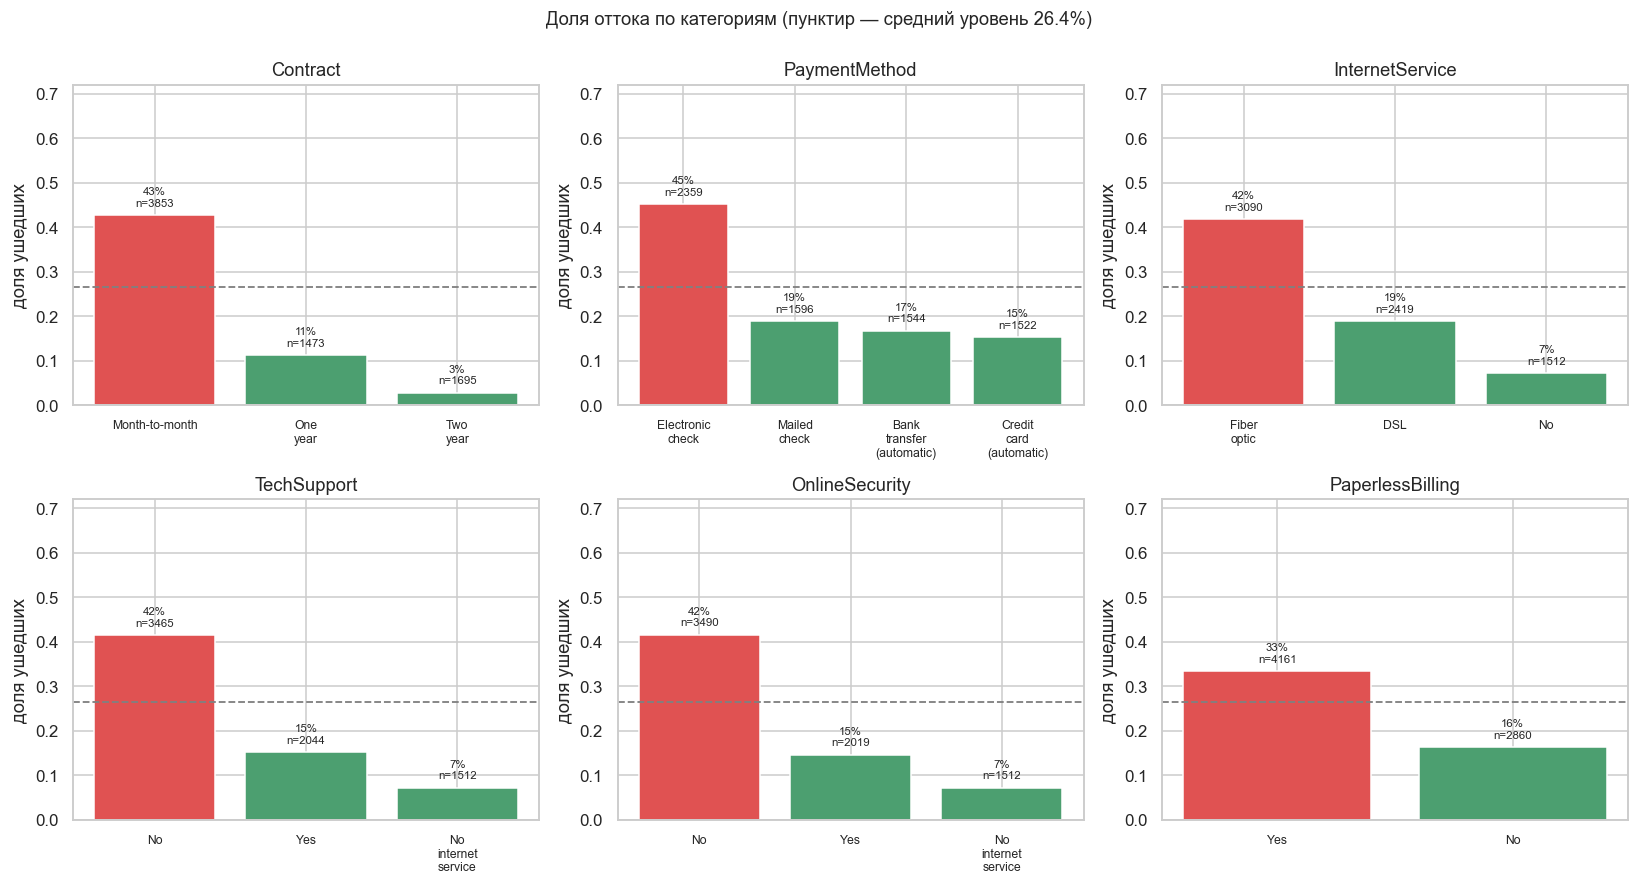

In [9]:
cat_cols = ["Contract", "PaymentMethod", "InternetService", "TechSupport",
            "OnlineSecurity", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
overall = df[TARGET].mean()

for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    size = df[col].value_counts()
    colors = ["#e05252" if v > overall else "#4c9f70" for v in rate.values]
    bars = ax.bar(range(len(rate)), rate.values, color=colors)
    ax.axhline(overall, ls="--", color="grey", lw=1.2)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([str(i).replace(" ", "\n") for i in rate.index], fontsize=8)
    ax.set(title=col, ylabel="доля ушедших", ylim=(0, 0.72))
    for i, (v, idx) in enumerate(zip(rate.values, rate.index)):
        ax.text(i, v + 0.02, f"{v:.0%}\nn={size[idx]}", ha="center", fontsize=7.5)

fig.suptitle("Доля оттока по категориям (пунктир - средний уровень 26.4%)", y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_categorical.png", dpi=130, bbox_inches="tight")
plt.show()

In [10]:
# то же самое числами: во сколько раз отток выше среднего
rows = []
for col in df.select_dtypes(include="object").columns:
    rate = df.groupby(col)[TARGET].mean()
    rows.append({"признак": col,
                 "худшая категория": rate.idxmax(),
                 "отток в ней": f"{rate.max():.1%}",
                 "лучшая категория": rate.idxmin(),
                 "отток в ней ": f"{rate.min():.1%}",
                 "разрыв, п.п.": round((rate.max() - rate.min()) * 100, 1)})

pd.DataFrame(rows).sort_values("разрыв, п.п.", ascending=False).reset_index(drop=True)

,признак,худшая категория,отток в ней,лучшая категория,отток в ней,"разрыв, п.п."
0,Contract,Month-to-month,42.6%,Two year,2.8%,39.8
1,InternetService,Fiber optic,41.8%,No,7.2%,34.6
2,OnlineSecurity,No,41.6%,No internet service,7.2%,34.4
3,TechSupport,No,41.5%,No internet service,7.2%,34.3
4,OnlineBackup,No,39.8%,No internet service,7.2%,32.6
5,DeviceProtection,No,39.0%,No internet service,7.2%,31.8
6,PaymentMethod,Electronic check,45.1%,Credit card (automatic),15.2%,29.9
7,StreamingMovies,No,33.5%,No internet service,7.2%,26.3
8,StreamingTV,No,33.3%,No internet service,7.2%,26.1
9,PaperlessBilling,Yes,33.4%,No,16.3%,17.1


### Вывод 2: портрет уходящего клиента уже виден

Самые сильные разрывы:

* **Тип контракта** - помесячный контракт: **43%** оттока против **3%** на двухлетнем.
  Разрыв в 40 процентных пунктов, это сильнейший сигнал во всём датасете.
  Логика человеческая: чтобы уйти с помесячного контракта, не нужно делать ничего -
  просто не заплатить. С двухлетнего уйти = потерять деньги.
* **Оптоволоконный интернет** - 42% оттока. На первый взгляд странно: это лучший
  и самый дорогой продукт. Гипотеза: дорого + завышенные ожидания по скорости.
* **Электронный чек** как способ оплаты - 45%. Клиент каждый месяц вручную
  совершает платёж, то есть каждый месяц заново принимает решение платить.
  У автоплатежа отток вдвое ниже.
* **Отсутствие техподдержки и онлайн-защиты** - около 40%.

Это уже готовый материал для бизнес-рекомендаций, ещё до всякого машинного обучения.

## 2.3. Вопрос третий: числовые признаки

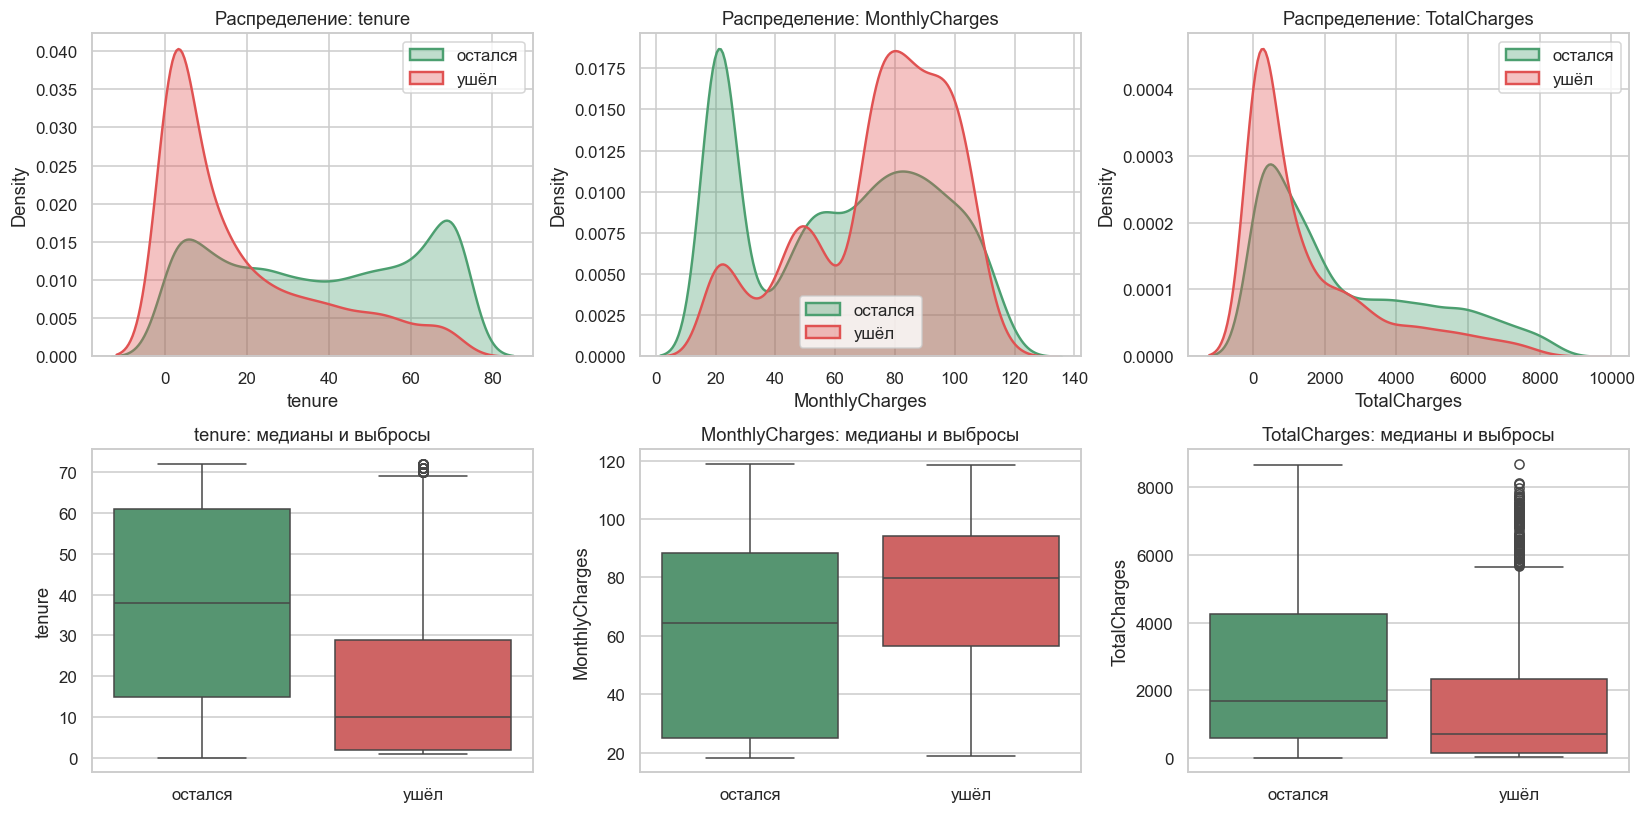

tenure       MonthlyCharges       TotalCharges        
      median  mean         median  mean       median    mean
Churn                                                       
0       38.0  37.6           64.5  61.3       1683.0  2554.8
1       10.0  18.1           79.7  74.6        713.1  1541.4

In [11]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))

for i, col in enumerate(num_cols):
    ax = axes[0, i]
    for val, name, c in [(0, "остался", "#4c9f70"), (1, "ушёл", "#e05252")]:
        sns.kdeplot(df[df[TARGET] == val][col], ax=ax, label=name,
                    fill=True, alpha=.35, color=c, lw=1.6)
    ax.set(title=f"Распределение: {col}", xlabel=col)
    ax.legend()

    ax2 = axes[1, i]
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax2, hue=TARGET,
                palette=["#4c9f70", "#e05252"], legend=False)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(["остался", "ушёл"])
    ax2.set(title=f"{col}: медианы и выбросы", xlabel="")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_numeric.png", dpi=130, bbox_inches="tight")
plt.show()

df.groupby(TARGET)[num_cols].agg(["median", "mean"]).round(1)

### Вывод 3

* **tenure (срок обслуживания)** - самое информативное число. У ушедших медиана
  **10 месяцев**, у оставшихся - **38**. У распределения ушедших виден резкий пик
  в первые месяцы: люди уходят в самом начале, пока привычка не сформировалась.
* **MonthlyCharges** - ушедшие платят заметно больше (медиана ≈ 79 против ≈ 64).
  Дорогой тариф = выше ожидания = проще разочароваться.
* **TotalCharges** - обманчивый признак. У ушедших он ниже, но это **следствие**
  короткого срока обслуживания, а не причина ухода: мало месяцев - мало заплачено.
  Это хороший пример разницы между корреляцией и причинностью.

## 2.4. Вопрос четвёртый: отток по сроку обслуживания

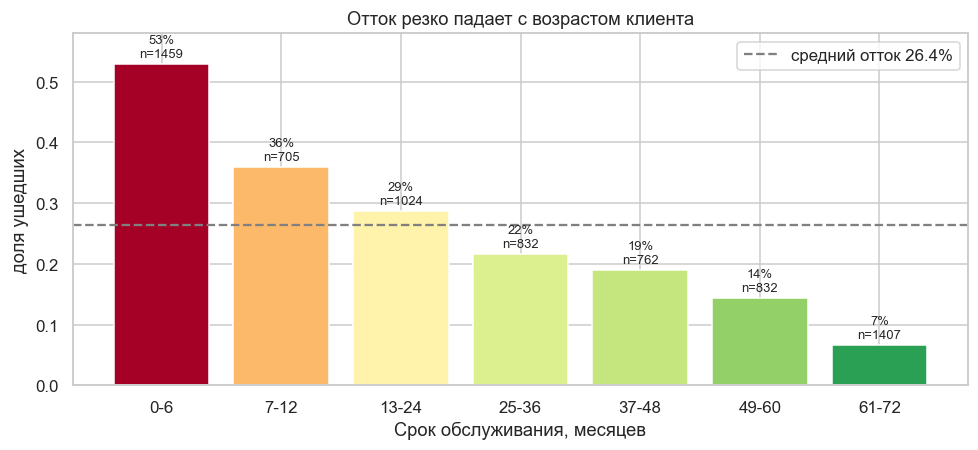

,_tenure_bin,churn_rate,n
0,0-6,0.529130,1459
1,7-12,0.358865,705
2,13-24,0.287109,1024
3,25-36,0.216346,832
4,37-48,0.190289,762
5,49-60,0.144231,832
6,61-72,0.066098,1407


In [12]:
bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ["0-6", "7-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df["_tenure_bin"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

grp = df.groupby("_tenure_bin", observed=True).agg(
    churn_rate=(TARGET, "mean"), n=(TARGET, "size")).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(grp["_tenure_bin"].astype(str), grp["churn_rate"],
              color=plt.cm.RdYlGn_r(grp["churn_rate"] / grp["churn_rate"].max()))
ax.axhline(df[TARGET].mean(), ls="--", color="grey", label="средний отток 26.4%")
for i, r in grp.iterrows():
    ax.text(i, r.churn_rate + 0.012, f"{r.churn_rate:.0%}\nn={r.n}", ha="center", fontsize=8.5)
ax.set(xlabel="Срок обслуживания, месяцев", ylabel="доля ушедших",
       title="Отток резко падает с возрастом клиента", ylim=(0, 0.58))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_tenure.png", dpi=130, bbox_inches="tight")
plt.show()
grp

### Вывод 4: главный практический инсайт проекта

Отток падает с **53%** в первые полгода до **6.6%** после пяти лет - в восемь раз.

Что это значит для бизнеса: **удерживать нужно в первые месяцы**. Клиент, проживший
с оператором два года, уходит редко сам по себе, и тратить на него retention-бюджет
почти бессмысленно. А вот новичок в первые полгода - зона, где каждый звонок окупается.

Именно поэтому дальше я добавлю признак `is_new` (первые 6 месяцев).

## 2.5. Вопрос пятый: корреляции и утечка данных

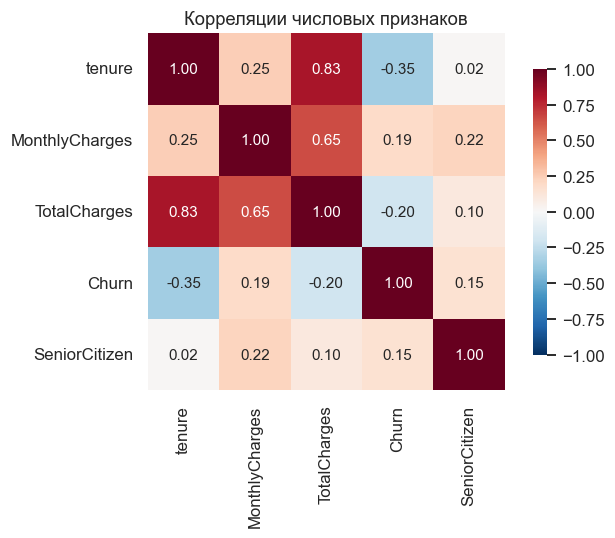

In [13]:
corr_df = df[num_cols + [TARGET]].copy()
corr_df["SeniorCitizen"] = df["SeniorCitizen"]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
ax.set(title="Корреляции числовых признаков")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

### Вывод 5: две важные вещи

**1. Мультиколлинеарность.** `TotalCharges` коррелирует с `tenure` на **0.83**.
Это почти одно и то же: «сумма всех платежей» ≈ «месяцев» × «платёж в месяц».
Для логистической регрессии это проблема - коэффициенты становятся неустойчивыми
и их нельзя интерпретировать. Для деревьев не критично. Решение: оставляю обе,
но добавляю производный признак `avg_monthly_spend = TotalCharges / tenure`,
который несёт уже другую информацию - реальный средний чек.

**2. Утечки данных нет.** Ни один признак не коррелирует с таргетом аномально
сильно (максимум `tenure` с −0.35). Если бы я увидел корреляцию 0.95, это почти
наверняка означало бы колонку вроде «дата расторжения договора» - то есть признак,
которого в момент прогноза ещё не существует. Такой признак дал бы ROC-AUC 0.99
в ноутбуке и полную бесполезность в проде.

**Отдельно про `gender`:** разрыв оттока между мужчинами и женщинами - меньше
процентного пункта. Признак бесполезен для модели, и это скорее хорошо:
пол в качестве драйвера решений создал бы этическую проблему.

In [14]:
df = df.drop(columns=["_tenure_bin"])   # служебная колонка больше не нужна
print("EDA завершён. Сохранённые графики:")
for p in sorted(FIGURES_DIR.glob("eda_*.png")):
    print("  ", p.name)

EDA завершён. Сохранённые графики:
   eda_categorical.png
   eda_correlation.png
   eda_numeric.png
   eda_target.png
   eda_tenure.png


---
## Итоги EDA: что я узнал до обучения модели

| # | Находка | Что с этим делать |
|---|---|---|
| 1 | Классы 26/74 | Метрика - ROC-AUC, не accuracy; `class_weight="balanced"` |
| 2 | Помесячный контракт: 43% оттока против 3% | Сильнейший признак; рычаг удержания №1 |
| 3 | Первые 6 месяцев: отток 53% | Признак `is_new`; фокус retention на новичках |
| 4 | Электронный чек: 45% оттока | Признак `auto_payment`; рычаг - перевод на автосписание |
| 5 | Нет техподдержки/защиты: ~40% | Признак `no_protection`; рычаг - бесплатное подключение |
| 6 | `TotalCharges` ≈ `tenure` × `MonthlyCharges` | Производный признак `avg_monthly_spend` |
| 7 | `gender` ничего не даёт | Оставляю, но не жду от него пользы |
| 8 | Утечек нет | Можно доверять будущим метрикам |

Обратите внимание: **шесть из восьми строк этой таблицы напрямую превращаются
в код на следующем шаге**. Так и должен работать EDA - не как отдельный
раздел «для галочки», а как источник решений.

---
# 3. Feature engineering

Модель не знает про телеком ничего. Она видит только те колонки, которые я ей дал.
Всё «понимание бизнеса» попадает в модель **только через признаки** - это и есть
feature engineering, и обычно он даёт больше, чем подбор гиперпараметров.

Семь признаков ниже - это прямой перевод выводов EDA в код. У каждого гипотеза:

| Признак | Формула | Гипотеза |
|---|---|---|
| `num_services` | сколько услуг подключено | одна услуга - легко уйти, шесть - тяжело |
| `avg_monthly_spend` | `TotalCharges / tenure` | реальный средний чек за всё время |
| `price_trend` | `MonthlyCharges / avg_monthly_spend` | `>1` значит счёт вырос - повод уйти |
| `price_per_service` | `MonthlyCharges / num_services` | ощущение «переплачиваю» |
| `is_new` | `tenure <= 6` | из вывода 4 EDA |
| `no_protection` | нет ни техподдержки, ни защиты | из вывода 5 EDA |
| `auto_payment` | оплата списывается автоматически | из вывода 4 EDA |

In [15]:
from features import add_features, split_columns

df_fe = add_features(df)
new_cols = ["num_services", "avg_monthly_spend", "price_trend",
            "price_per_service", "is_new", "no_protection", "auto_payment"]

print("Признаков было:", df.shape[1] - 1, "-> стало:", df_fe.shape[1] - 1)
df_fe[new_cols].describe().round(2)

Признаков было: 19 -> стало: 26


,num_services,avg_monthly_spend,price_trend,price_per_service,is_new,no_protection,auto_payment
count,7021.00,7021.00,7021.00,7021.00,7021.00,7021.00,7021.00
mean,3.37,64.79,1.00,22.47,0.21,0.58,0.44
std,2.06,30.25,0.05,11.50,0.41,0.49,0.50
min,0.00,0.00,0.64,10.42,0.00,0.00,0.00
25%,1.00,36.20,0.98,15.69,0.00,0.00,0.00
50%,3.00,70.45,1.00,19.75,0.00,1.00,0.00
75%,5.00,90.20,1.02,24.50,0.00,1.00,1.00
max,8.00,121.40,1.45,72.25,1.00,1.00,1.00


In [16]:
# Проверяем гипотезы: отличаются ли новые признаки у ушедших и оставшихся?
comparison = df_fe.groupby(TARGET)[new_cols].mean().T
comparison.columns = ["остался", "ушёл"]
comparison["разница"] = comparison["ушёл"] - comparison["остался"]
comparison.round(3).sort_values("разница", key=abs, ascending=False)

,остался,ушёл,разница
avg_monthly_spend,61.261,74.596,13.335
price_per_service,20.334,28.402,8.069
num_services,3.451,3.146,-0.305
is_new,0.133,0.416,0.283
auto_payment,0.499,0.264,-0.235
no_protection,0.524,0.728,0.204
price_trend,1.002,1.003,0.001


**Читаем таблицу честно.**

* `is_new`: у ушедших 0.41 против 0.14 - гипотеза подтвердилась ярко.
* `no_protection`: 0.73 против 0.52 - подтвердилась.
* `auto_payment`: 0.26 против 0.50 - подтвердилась (автоплатёж удерживает).
* `num_services`: разница есть, но небольшая.
* `price_trend`: разница почти нулевая - **гипотеза не подтвердилась**.

Последний пункт я оставляю в проекте специально. Признак, который не сработал, -
это нормальный результат исследования, а не ошибка. Скрывать его было бы
подгонкой отчёта под красивый результат.

## 3.1. А окупился ли feature engineering? (ablation-тест)

Придумать признаки легко. Доказать, что они что-то дали, - сложнее.
Обучаю одну и ту же модель дважды: со всеми признаками и без новых.

In [17]:
from sklearn.model_selection import train_test_split
from config import TEST_SIZE
from train import ablation_test

X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f"train: {X_train.shape},  test: {X_test.shape}")
print(f"доля оттока - train {y_train.mean():.3f}, test {y_test.mean():.3f}\n")

abl = ablation_test(X_train, y_train)
for name, v in abl.items():
    print(f"{name:22} ROC-AUC = {v['roc_auc_mean']:.4f} ± {v['roc_auc_std']:.4f}")
delta = abl["с новыми признаками"]["roc_auc_mean"] - abl["только исходные"]["roc_auc_mean"]
print(f"\nПрирост: {delta:+.4f}")

train: (5616, 26),  test: (1405, 26)
доля оттока - train 0.264, test 0.265



с новыми признаками    ROC-AUC = 0.8482 ± 0.0161
только исходные        ROC-AUC = 0.8458 ± 0.0154

Прирост: +0.0024


**Честный вывод.** Прирост **+0.0024 ROC-AUC**, а разброс между фолдами
кросс-валидации - **±0.016**, то есть в шесть раз больше самого прироста.

Значит, правильная формулировка такая: *«новые признаки дали небольшой плюс,
но он статистически неотличим от шума»*. Не «признаки улучшили модель на 0.24%».

Почему так вышло? Потому что мои признаки - это комбинации уже имеющихся
(`is_new` - это функция от `tenure`, `no_protection` - от двух колонок про услуги).
Градиентный бустинг умеет находить такие комбинации сам. Feature engineering даёт
большой эффект там, где нужна **внешняя информация**, которой в таблице нет:
курс валют, праздники, данные конкурентов, история обращений в поддержку.

Зачем тогда оставляю? Признаки ничего не ломают, а `is_new` и `no_protection`
делают объяснения для менеджера понятнее. Это плата не за метрику, а за интерпретируемость.

---
# 4. Моделирование

## 4.1. Схема проверки: почему нельзя просто split и всё

Разбиваю данные **один раз** и тест не трогаю до самого конца.

```
все данные (7021)
├── train (5616)  -> здесь 5-fold кросс-валидация, выбор модели, подбор гиперпараметров
└── test  (1405)  -> открываю ОДИН раз в конце
```

Если выбирать победителя по тесту, тест перестаёт быть честным: я фактически
подгоняюсь под него и получаю завышенную оценку. `stratify=y` обязателен -
иначе доля оттока в тесте случайно окажется другой, и метрики станут несравнимы.

## 4.2. Baseline: с чего всегда начинают

Baseline - простая модель, которую всё остальное обязано побить. Без неё
непонятно, хорош ли ROC-AUC 0.84: может, его даёт одна строчка кода.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from features import build_pipeline

numeric, categorical = split_columns(X_train)
print(f"числовых: {len(numeric)}, категориальных: {len(categorical)}")

# Нулевой уровень: модель, которая всегда говорит «останется»
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print(f"\n[Заглушка] accuracy = {accuracy_score(y_test, dummy_pred):.3f}, "
      f"ROC-AUC = {roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]):.3f}, "
      f"найдено уходящих = {int(dummy_pred.sum())}")

# Baseline: логистическая регрессия
logreg = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    numeric, categorical).fit(X_train, y_train)
base_proba = logreg.predict_proba(X_test)[:, 1]
print(f"[Baseline] accuracy = {accuracy_score(y_test, (base_proba >= .5).astype(int)):.3f}, "
      f"ROC-AUC = {roc_auc_score(y_test, base_proba):.3f}, "
      f"F1 = {f1_score(y_test, (base_proba >= .5).astype(int)):.3f}")

числовых: 11, категориальных: 15

[Заглушка] accuracy = 0.735, ROC-AUC = 0.500, найдено уходящих = 0


[Baseline] accuracy = 0.752, ROC-AUC = 0.842, F1 = 0.624


Вот она, ловушка accuracy, в одной таблице: заглушка даёт **73.5% accuracy**
и не находит **ни одного** уходящего клиента (ROC-AUC ровно 0.5 - уровень монетки).
Логистическая регрессия даёт accuracy **ниже**, но ROC-AUC **0.84**. По accuracy
заглушка «выигрывает», по делу - она бесполезна.

## 4.3. Пайплайн: почему не `pd.get_dummies`

Категории нужно закодировать числами, числа - отмасштабировать. Соблазн -
сделать это прямо в ноутбуке через `pd.get_dummies()`. Так делать **нельзя**,
и вот почему:

* на одном клиенте `get_dummies` создаст другой набор колонок, и модель упадёт;
* масштабирование, посчитанное до `train_test_split`, использует информацию
  из теста - это утечка;
* при кросс-валидации то же самое повторится на каждом фолде.

`Pipeline` + `ColumnTransformer` решают всё сразу: препроцессор запоминает
категории и средние **только по обучающей части фолда** и повторяет их один
в один на новых данных. И сохраняется всё это одним файлом `model.pkl`.

## 4.4. Сравнение моделей на кросс-валидации

In [19]:
from train import compare_models

cv_table = compare_models(X_train, y_train, numeric, categorical)
cv_table.round(4)

,model,ROC-AUC,ROC-AUC std,PR-AUC,F1,Recall,Precision
0,Baseline: LogisticRegression,0.8482,0.0161,0.6592,0.6386,0.8088,0.5279
1,RandomForest,0.8441,0.0179,0.6545,0.6305,0.7044,0.5709
2,XGBoost,0.8378,0.0191,0.6467,0.6250,0.7461,0.5378


### Неожиданный (и очень полезный) результат

**Логистическая регрессия обошла и Random Forest, и XGBoost.**

Это не ошибка и не редкость. Объяснение простое: после one-hot кодирования
зависимость «отток ↔ признаки» в этих данных близка к линейной. Помесячный
контракт повышает риск, длинный срок обслуживания понижает - никаких сложных
взаимодействий, на которых бустинг обычно выигрывает. А данных всего 5.6 тысячи
строк: ансамблям с сотнями деревьев тут просто негде развернуться.

Вывод для себя: **«взял XGBoost» ещё не значит «сделал лучше»**.
Сложная модель должна выиграть по метрике, а не просто считаться более крутой.

## 4.5. Подбор гиперпараметров - обоим финалистам

Типичная ошибка: настроить бустинг, сравнить с ненастроенной регрессией и
объявить бустинг победителем. Сравнивать нужно настроенное с настроенным,
поэтому `GridSearchCV` запускаю для обеих моделей.

In [20]:
from train import tune_all

searches = tune_all(X_train, y_train, numeric, categorical)
for name, s in searches.items():
    print(f"{name:28} CV ROC-AUC = {s.best_score_:.4f}")
    print(f"   лучшие параметры: {s.best_params_}\n")

best_name = max(searches, key=lambda n: searches[n].best_score_)
best_pipe = searches[best_name].best_estimator_
print(f"Победитель: {best_name}")

LogisticRegression (tuned)   CV ROC-AUC = 0.8482
   лучшие параметры: {'model__C': 1.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

XGBoost (tuned)              CV ROC-AUC = 0.8497
   лучшие параметры: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.02, 'model__max_depth': 2, 'model__min_child_weight': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}

Победитель: XGBoost (tuned)


**Разбор.** После настройки XGBoost вышел вперёд: **0.8497** против **0.8482**.
Но посмотрите на масштаб разницы - **0.0015**, при разбросе между фолдами ±0.016.
Честная формулировка: *модели практически равны, XGBoost выигрывает в пределах шума*.

Интересно, какие параметры выбрал GridSearch: `max_depth=2`, `learning_rate=0.02`,
`min_child_weight=5`. Это максимально **зарегуляризованный** бустинг - почти
«пеньки» вместо деревьев. Модель сама говорит нам: данные простые, сложность вредна.

Беру XGBoost, потому что он победил по CV, но в разделе «что дальше» отмечу:
для продакшена логистическая регрессия была бы разумнее - она быстрее,
её коэффициенты интерпретируются напрямую, и результат тот же.

## 4.6. Финальная проверка на отложенном тесте

Момент истины: открываю тест первый и единственный раз.

In [21]:
from sklearn.metrics import (average_precision_score, classification_report,
                             roc_curve, precision_recall_curve)

proba = best_pipe.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, proba)
test_ap = average_precision_score(y_test, proba)

print(f"ROC-AUC на кросс-валидации: {searches[best_name].best_score_:.4f}")
print(f"ROC-AUC на тесте:           {test_auc:.4f}")
print(f"PR-AUC  на тесте:           {test_ap:.4f}")
print(f"\nBaseline (LogReg) на тесте: {roc_auc_score(y_test, base_proba):.4f}")

ROC-AUC на кросс-валидации: 0.8497
ROC-AUC на тесте:           0.8426
PR-AUC  на тесте:           0.6605

Baseline (LogReg) на тесте: 0.8416


**Главная проверка на переобучение:** CV дал 0.8497, тест - 0.8426. Разрыв
**0.007** - это отлично. Если бы на CV было 0.95, а на тесте 0.84, это означало бы,
что модель запомнила обучающие данные, и нужно было бы усиливать регуляризацию.

## 4.7. Какие признаки оказались важны

In [22]:
from train import get_feature_importances

imp = get_feature_importances(best_pipe)
fig, ax = plt.subplots(figsize=(8.5, 6))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="#2a6f97")
ax.set(xlabel="важность", title=f"Топ-15 признаков - {best_name}")
fig.tight_layout(); plt.show()
imp.head(10).round(4)

Contract_Month-to-month           0.3022
OnlineSecurity_No                 0.1154
TechSupport_No                    0.0785
InternetService_Fiber optic       0.0575
PaymentMethod_Electronic check    0.0471
is_new                            0.0422
Contract_One year                 0.0420
Contract_Two year                 0.0396
InternetService_No                0.0301
tenure                            0.0264
dtype: float32

**Модель подтвердила EDA, и это хороший знак.** На первых местах - тип контракта,
срок обслуживания, оптоволоконный интернет, электронный чек. Ровно то, что мы
увидели на графиках вручную. Когда модель «согласна» с разведочным анализом,
вероятность, что где-то ошибка, заметно ниже.

Важная оговорка: `feature_importances_` у бустинга показывает **силу** влияния,
но не **направление**. Из неё нельзя узнать, повышает признак риск или понижает.
Для направления нужны коэффициенты линейной модели или SHAP - поэтому для
объяснения конкретного клиента я использую другой метод (раздел 6).

---
# 5. Порог: место, где ML встречается с деньгами

Модель выдаёт вероятность. Чтобы принять решение «звонить или нет», нужен порог.
**0.5 - это не закон природы, а значение по умолчанию.** Правильный порог
считается из экономики.

Вводные (условные, но структура реальная):

| Параметр | Значение |
|---|---|
| Стоимость контакта (звонок + скидка) | 20 у.е. |
| Маржа удержанного клиента | 200 у.е. |
| Вероятность, что предложение сработает | 25% |

Ценность одного успешного контакта = `0.25 × 200 = 50` у.е.
Звонить выгодно, пока **precision > 20/50 = 0.4**. Это «точка безубыточности».

Множитель «предложение срабатывает в 25% случаев» - ключевой. Без него получается,
что мы удерживаем всех, кому позвонили, и модель советует обзванивать всю базу.

In [23]:
from train import profit_table
from config import BREAK_EVEN_PRECISION

thr = profit_table(y_test.values, proba)
best_t = float(thr.loc[thr["profit"].idxmax(), "threshold"])
row_best = thr[thr.threshold == best_t].iloc[0]
row_half = thr[thr.threshold == 0.50].iloc[0]

print(f"Точка безубыточности по precision: {BREAK_EVEN_PRECISION:.2f}\n")
print(f"{'порог':>6} {'прибыль':>9} {'обзвон':>7} {'recall':>7} {'precision':>10}")
for r in (row_half, row_best):
    print(f"{r.threshold:>6.2f} {r.profit:>9.0f} {int(r.contacted):>7} "
          f"{r.recall:>7.3f} {r.precision:>10.3f}")
print(f"\nВыигрыш от правильного порога: {row_best.profit - row_half.profit:+.0f} у.е. "
      f"({(row_best.profit / row_half.profit - 1):+.0%})")

Точка безубыточности по precision: 0.40

 порог   прибыль  обзвон  recall  precision
  0.50      3140     583   0.796      0.508
  0.64      4150     395   0.648      0.610

Выигрыш от правильного порога: +1010 у.е. (+32%)


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))

ax[0].plot(thr["threshold"], thr["profit"], lw=2, color="#2a6f97")
ax[0].axvline(best_t, color="#e05252", ls="--", label=f"оптимум {best_t}")
ax[0].axvline(0.5, color="grey", ls=":", label="по умолчанию 0.5")
ax[0].set(xlabel="порог вероятности", ylabel="прибыль на тесте, у.е.",
          title="Прибыль зависит от порога")
ax[0].legend()

ax[1].plot(thr["threshold"], thr["precision"], label="precision", lw=2)
ax[1].plot(thr["threshold"], thr["recall"], label="recall", lw=2)
ax[1].plot(thr["threshold"], thr["f1"], label="F1", lw=2, ls="--")
ax[1].axhline(BREAK_EVEN_PRECISION, color="#e05252", ls=":", label="безубыточность 0.4")
ax[1].axvline(best_t, color="grey", ls="--", lw=1)
ax[1].set(xlabel="порог вероятности", ylabel="значение метрики",
          title="Precision и recall тянут в разные стороны")
ax[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "threshold_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

**Что показывают графики.** Оптимальный порог - **0.64**, а не 0.5. При нём
обзваниваем 395 клиентов вместо 583, ловим меньше уходящих (recall 0.65 против 0.80),
зато точнее (precision 0.61 против 0.51) - и зарабатываем **на 32% больше**.

Правый график объясняет, почему так: чем ниже порог, тем больше клиентов мы
ловим, но тем больше среди них ложных тревог. Каждая ложная тревога - это
потраченные 20 у.е. Экономика находит точку равновесия.

## 5.1. Взгляд, который ближе к реальности: ограниченная ёмкость

На практике вопрос звучит не «какой порог», а **«у нас 5 операторов, они
обзванивают 10% базы в месяц - кого выбрать?»**. Здесь работает метрика **lift**:
во сколько раз наш список лучше случайного обзвона.

In [25]:
from train import capacity_report

cap = capacity_report(y_test.values, proba)
cap

,доля базы,клиентов обзвонили,из них реально ушли,precision@k,lift,охват оттока (recall)
0,5%,70,60,0.857,3.24,0.161
1,10%,140,100,0.714,2.70,0.269
2,20%,281,186,0.662,2.50,0.500


### Главная цифра проекта для бизнеса

Если обзвонить **топ-5%** самых рискованных клиентов по версии модели,
**86%** из них действительно собирались уйти. При случайном обзвоне попадание
было бы 26%. **Lift = 3.24** - модель в три с лишним раза эффективнее.

Именно эту цифру я бы назвал первой на защите: она понятна человеку,
который не знает, что такое ROC-AUC.

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

pred = (proba >= best_t).astype(int)
print(classification_report(y_test, pred, target_names=["остался", "ушёл"], digits=3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["остался", "ушёл"],
                                        cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set(title=f"Матрица ошибок, порог {best_t}")

fpr, tpr, _ = roc_curve(y_test, proba)
b_fpr, b_tpr, _ = roc_curve(y_test, base_proba)
ax[1].plot(fpr, tpr, lw=2, label=f"{best_name} (AUC={test_auc:.3f})")
ax[1].plot(b_fpr, b_tpr, lw=1.6, ls="--", label=f"Baseline LogReg (AUC={roc_auc_score(y_test, base_proba):.3f})")
ax[1].plot([0, 1], [0, 1], color="grey", ls=":", label="случайная модель")
ax[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC-кривые")
ax[1].legend()
fig.tight_layout(); plt.show()

              precision    recall  f1-score   support

     остался      0.870     0.851     0.860      1033
        ушёл      0.610     0.648     0.628       372

    accuracy                          0.797      1405
   macro avg      0.740     0.749     0.744      1405
weighted avg      0.801     0.797     0.799      1405



**Читаем матрицу ошибок по-человечески (на 1405 клиентах теста):**

* **241 клиента** мы верно определили как уходящих и успели позвонить;
* **131 уходящего** пропустили - они ушли молча (это цена высокого порога);
* **154 лояльных** потревожили зря - потратили на них бюджет;
* **879 лояльных** справедливо не трогали.

Две ROC-кривые практически совпадают - ещё одно наглядное подтверждение,
что baseline здесь почти не уступает бустингу.

---
# 6. AI-часть: объяснение для менеджера

Гибридный проект - это не «ML отдельно, LLM отдельно». Это разделение труда:

* **ML отвечает на вопрос «сколько»** - вероятность, факторы, сценарии. Всё считается.
* **LLM отвечает на вопрос «объясни»** - превращает цифры в текст. Ничего не считает.

Почему нельзя просто спросить у LLM «уйдёт ли этот клиент»? Она не видела наши
7 тысяч клиентов и не знает статистику оттока - она выдаст правдоподобно звучащее,
но произвольное число. Такой ответ нельзя измерить метрикой и нельзя воспроизвести.

## 6.1. Локальное объяснение: почему у ЭТОГО клиента такой риск

`feature_importances_` говорит, что важно «вообще». Менеджеру нужно знать,
что важно **у конкретного клиента**. Метод простой и полностью прозрачный:
берём поле клиента, подменяем на типичное по базе, спрашиваем модель заново.
Насколько упала вероятность - таков вклад поля. Это ручной аналог SHAP.

In [27]:
from predict import analyze

risky_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.0, "TotalCharges": 190.0,
}

res = analyze(risky_customer)
print(f"Вероятность ухода: {res['percent']}%   порог: {res['threshold']}   "
      f"риск: {res['risk_level']}\n")
print("Что повышает риск именно у него:")
for d in res["drivers"]:
    print(f"  {d['feature_ru']:24} {str(d['value']):18} вклад {d['effect']*100:+5.1f} п.п.")

Вероятность ухода: 89.4%   порог: 0.64   риск: высокий

Что повышает риск именно у него:
  срок обслуживания        2                  вклад +18.5 п.п.
  ежемесячный платёж       95.0               вклад  +1.3 п.п.
  ТВ-стриминг              Yes                вклад  +0.7 п.п.
  онлайн-кинотеатр         Yes                вклад  +0.7 п.п.
  сумма всех платежей      190.0              вклад  +0.3 п.п.


**Тонкий момент, который стоит понимать.** В списке нет типа контракта - хотя
по EDA это сильнейший фактор. Почему? Потому что метод сравнивает клиента
**с типичным**, а помесячный контракт и есть самый частый в базе. Клиент
не отличается от большинства по этому полю, поэтому оно и не «выделяется».

Это ограничение метода, и его нужно знать: он показывает **отличия от типичного
клиента**, а не абсолютный вклад. SHAP считает честнее, но требует библиотеки
и объясняется сложнее. Для рычагов удержания это ограничение снимается следующим шагом.

## 6.2. Сценарии «что если»: что предложить клиенту

Самое полезное для бизнеса. Не «клиент уйдёт с вероятностью 0.89»,
а «предложите двухлетний контракт - риск упадёт до 0.64».

In [28]:
print(f"Текущий риск: {res['percent']}%\n")
print("Рассчитанные сценарии удержания:")
for a in res["actions"]:
    print(f"  {a['action']:38} риск -> {a['new_proba']*100:5.1f}%   "
          f"(−{a['delta']*100:.1f} п.п.)")

Текущий риск: 89.4%

Рассчитанные сценарии удержания:
  Перевести на двухлетний контракт       риск ->  64.1%   (−25.2 п.п.)
  Перевести на годовой контракт          риск ->  75.5%   (−13.8 п.п.)
  Подключить онлайн-защиту               риск ->  82.8%   (−6.6 п.п.)


Вот здесь тип контракта и проявился: смена на двухлетний снижает риск
на **25 процентных пунктов** - сильнее любого другого рычага. EDA это предсказал.

## 6.3. LLM превращает цифры в текст

In [29]:
from ai_explain import generate_explanation, build_prompt

print("=== ПРОМПТ, который уходит в LLM (только факты от ML-модели) ===\n")
print(build_prompt(risky_customer, res))

=== ПРОМПТ, который уходит в LLM (только факты от ML-модели) ===

КЛИЕНТ:
  срок обслуживания: 2 мес.
  контракт: Month-to-month
  интернет: Fiber optic
  ежемесячный платёж: 95.0 у.е.
  способ оплаты: Electronic check

РЕЗУЛЬТАТ МОДЕЛИ (XGBoost (tuned)):
  вероятность ухода: 89.4%
  порог тревоги: 64%
  уровень риска: высокий

ГЛАВНЫЕ ПРИЧИНЫ РИСКА:
  - срок обслуживания: 2 (вклад в риск +0.19)
  - ежемесячный платёж: 95.0 (вклад в риск +0.01)
  - ТВ-стриминг: Yes (вклад в риск +0.01)
  - онлайн-кинотеатр: Yes (вклад в риск +0.01)
  - сумма всех платежей: 190.0 (вклад в риск +0.00)

РАССЧИТАННЫЕ СЦЕНАРИИ УДЕРЖАНИЯ:
  - Перевести на двухлетний контракт: риск снизится до 64% (на 25 п.п.)
  - Перевести на годовой контракт: риск снизится до 76% (на 14 п.п.)
  - Подключить онлайн-защиту: риск снизится до 83% (на 7 п.п.)


In [30]:
out = generate_explanation(risky_customer, res)
print(f"=== ОТВЕТ  (источник: {out['source']}) ===\n")
print(out["text"])

=== ОТВЕТ  (источник: offline-шаблон) ===

Риск ухода высокий - 89.4% при пороге 64%. Клиента стоит взять в работу сейчас.

Основные причины: срок обслуживания - 2; ежемесячный платёж - 95.0; ТВ-стриминг - Yes.

Рекомендация: перевести на двухлетний контракт - по расчёту модели риск снизится до 64% (минус 25 п.п.). Запасные варианты: перевести на годовой контракт, подключить онлайн-защиту.


**Про источник ответа.** Если переменной окружения `OPENAI_API_KEY` нет,
приложение отдаёт офлайн-шаблон - тот же смысл, но суше. Это сделано намеренно:
демо на защите не должно падать из-за отсутствия интернета или ключа.
С ключом текст становится более связным и человеческим, цифры остаются те же.

**Два правила безопасности, зашитые в промпт:**

1. *«Используй только переданные числа, не придумывай новые»* - защита от
   галлюцинаций. Без этой строчки LLM охотно добавит «по статистике отрасли 30%...».
2. `temperature = 0.3` - нам нужна предсказуемость, а не творчество.

И главное: **ключ берётся из переменной окружения, а не из кода.**
Выложенный в GitHub API-ключ - классическая и дорогая ошибка.

---
# 7. Выводы

## Что получилось

| Что | Результат |
|---|---|
| Лучшая модель | XGBoost (настроенный), ROC-AUC **0.843** на тесте |
| Baseline | Логистическая регрессия, ROC-AUC **0.842** - практически столько же |
| Порог | **0.64** по экономике вместо 0.5 → прибыль выше на **32%** |
| Бизнес-эффект | топ-5% списка: **86%** попаданий, **lift 3.2×** |
| Продукт | веб-приложение на FastAPI: прогноз + объяснение + рекомендации |

## Что было сложно

1. **Честно признать, что baseline не хуже бустинга.** Хотелось написать
   «XGBoost улучшил результат», но разница 0.0015 при разбросе 0.016 - это шум.
2. **Экономика порога.** Первая версия давала порог 0.16 и совет «обзвонить 60%
   базы». Ошибка была в том, что я не учёл: предложение об удержании срабатывает
   не всегда. С коэффициентом 25% всё встало на место.
3. **Дубликаты без ID.** Пришлось выбирать между риском утечки и потерей данных.

## Что улучшил бы дальше

* **SHAP** вместо самодельного метода объяснений - честнее считает вклад признаков.
* **Калибровка вероятностей** (`CalibratedClassifierCV`): сейчас «0.89» означает
  «высокий риск», но не строго «89 из 100 таких клиентов уйдут».
* **Данные, которых нет в таблице**: обращения в поддержку, скорость интернета,
  жалобы. Именно внешняя информация, а не новые комбинации старых колонок,
  дала бы реальный скачок качества.
* **Мониторинг дрейфа**: поведение клиентов меняется, модель нужно переобучать.
* **A/B-тест**: все выводы про удержание основаны на корреляциях. Утверждать,
  что перевод на двухлетний контракт **причинно** снижает отток, можно только
  после эксперимента.

## Честные ограничения

* Данные статичные, без временной метки - реальный отток сезонный.
* Экономические параметры (20 / 200 / 25%) взяты условно; в реальном проекте
  их даёт финансовый отдел, и порог изменится вместе с ними.
* `lift 3.2×` посчитан на одном тестовом разбиении - доверительный интервал
  вокруг этой цифры не считался.